> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


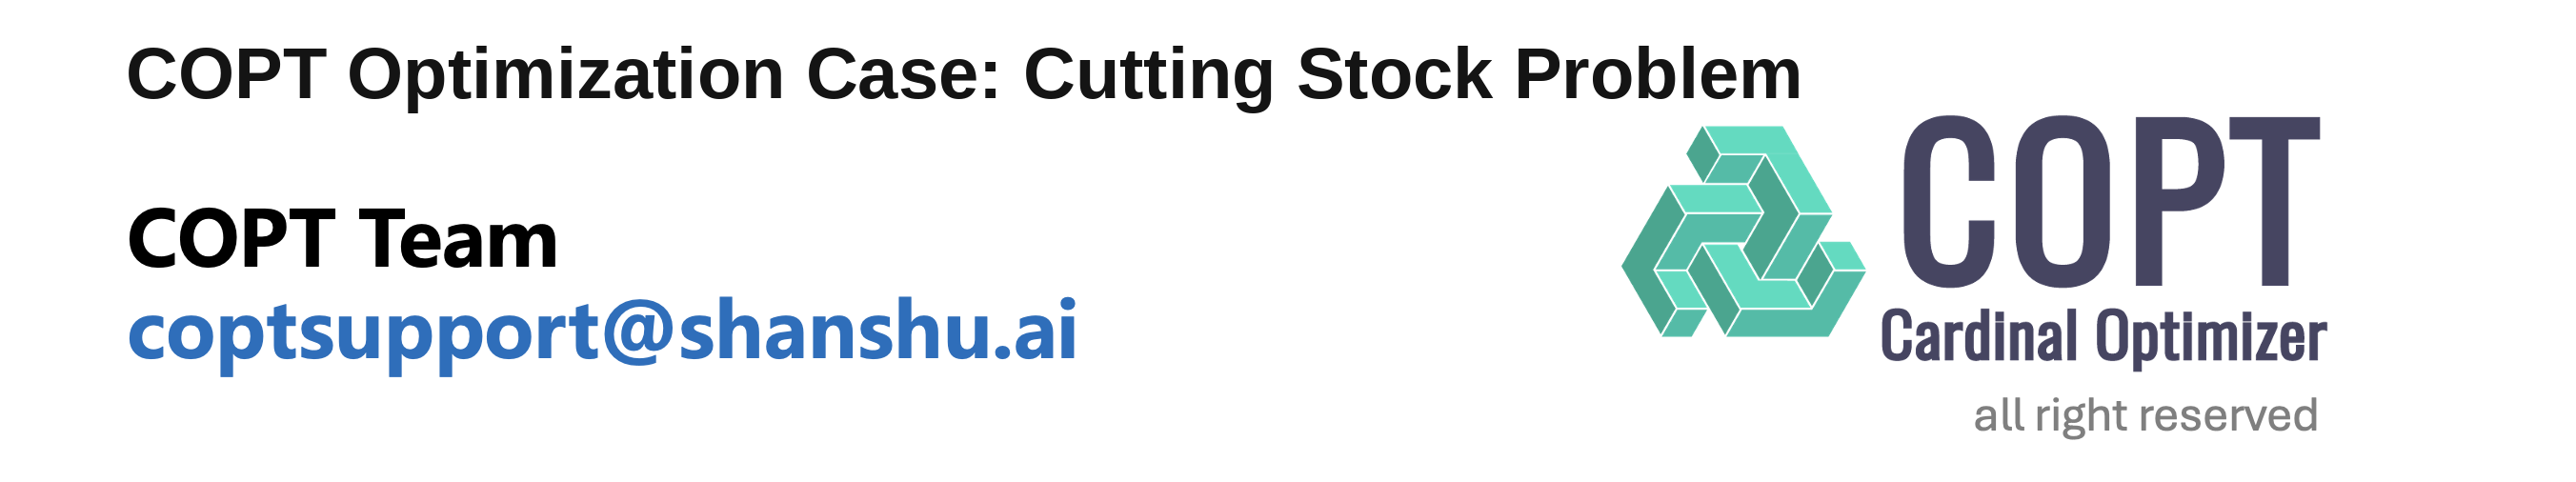

# Cutting Stock Problem Code Implementation
## Steps to Model and Solve the Cutting Stock Problem Using COPT

1. **Import the COPT-Python API** `coptpy`, together with `matplotlib` for plotting

2. **Add model data**
    - Log length, board lengths and demands
    - Enumerate all feasible cutting patterns recursively and visualize them

3. **Create the COPT environment and model**

4. **Build the model: add the three core components in turn**
    - **Decision variables**:
        - $x_j$: non-negative integer variable, the number of logs cut with pattern $j$
    - **Objective function**: minimize the total number of logs used
    - **Constraints**:
        - The total output of each board type is at least its demand

5. **Solve**

6. **Retrieve and analyze the results**: print and plot the optimal cutting plan, compare demand with output

7. **Case expansion**: speed up the solution with column generation
    - Build the restricted master problem and the pricing subproblem
    - Generate new patterns iteratively and track the objective value and shadow prices
    - Restore integrality to obtain the final plan, and compare both approaches on a larger instance

The mathematical model and the meaning of each symbol are given in the case description; the code below follows the steps above.

## Import COPT-Python API
Besides `coptpy`, `matplotlib` is imported for plotting. Each board type is given a fixed color so that it looks the same in every chart; trim loss is drawn in gray.

In [1]:
import math
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt

# Chart colors: one color per board type, gray for trim loss
COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
WASTE_COLOR = '#d9d8d4'

## Add Model Data
The logs are 20 m long. The four board lengths are 3, 7, 9 and 16 m with demands of 25, 30, 14 and 8 pieces. The $i$-th elements of the lists `types` and `demand` correspond to $l_i$ and $d_i$ in the mathematical model.

In [2]:
length = 20                # log length L (m)
types  = [3, 7, 9, 16]     # board lengths l_i (m)
demand = [25, 30, 14, 8]   # demands d_i (pieces)
num_types = len(types)

### Enumerate the Feasible Cutting Patterns
Each variable in the model corresponds to one cutting pattern, so all feasible patterns have to be listed before the model can be built. A pattern is stored as a list `[a1, a2, a3, a4]`, giving the number of 3 m, 7 m, 9 m and 16 m boards cut from one log; it is feasible whenever $3a_1 + 7a_2 + 9a_3 + 16a_4 \leq 20$.

The function below fixes the board counts one type at a time by recursion: first decide how many 3-m boards to cut, then how many 7-m boards fit in the remaining length, and so on. Once the last type has been handled, a complete pattern is obtained. The all-zero pattern (cutting nothing) is meaningless and is skipped.

Some of the enumerated patterns do not use the log fully, e.g. a single 3-m board with 17 m left over. Such patterns never appear in an optimal solution, because cutting the leftover into additional boards violates no constraint. They are kept here only so that the code matches the set $J$ of the mathematical model; they have no effect on the result.

In [3]:
def enumerate_patterns(length, types):
    """Enumerate all non-zero feasible cutting patterns; each pattern is a list of board counts per type"""
    patterns = []

    def recurse(idx, remaining, current):
        if idx == len(types):
            if any(current):
                patterns.append(current.copy())
            return
        for k in range(remaining // types[idx], -1, -1):
            current[idx] = k
            recurse(idx + 1, remaining - k * types[idx], current)
        current[idx] = 0

    recurse(0, length, [0] * len(types))
    return patterns


plans = enumerate_patterns(length, types)
num_plans = len(plans)

print(f'Log length {length} m, board lengths {types} m: {num_plans} feasible cutting patterns\n')
print('Pattern  ' + '  '.join(f'{t:>3}m' for t in types) + '   waste')
for j, plan in enumerate(plans):
    waste = length - sum(a * l for a, l in zip(plan, types))
    print(f'{j:>6}   ' + '  '.join(f'{a:>4}' for a in plan) + f'   {waste:>5}')

Log length 20 m, board lengths [3, 7, 9, 16] m: 23 feasible cutting patterns

Pattern    3m    7m    9m   16m   waste
     0      6     0     0     0       2
     1      5     0     0     0       5
     2      4     1     0     0       1
     3      4     0     0     0       8
     4      3     1     0     0       4
     5      3     0     1     0       2
     6      3     0     0     0      11
     7      2     2     0     0       0
     8      2     1     0     0       7
     9      2     0     1     0       5
    10      2     0     0     0      14
    11      1     2     0     0       3
    12      1     1     1     0       1
    13      1     1     0     0      10
    14      1     0     1     0       8
    15      1     0     0     1       1
    16      1     0     0     0      17
    17      0     2     0     0       6
    18      0     1     1     0       4
    19      0     1     0     0      13
    20      0     0     2     0       2
    21      0     0     1     0      11
  

Each row of the table is one pattern and the last column is the trim loss per log. A picture makes this easier to read: below, every pattern is drawn as a log lying horizontally, with colored segments for the boards and a gray segment for the trim loss. The plotting function is reused later to display the solutions.

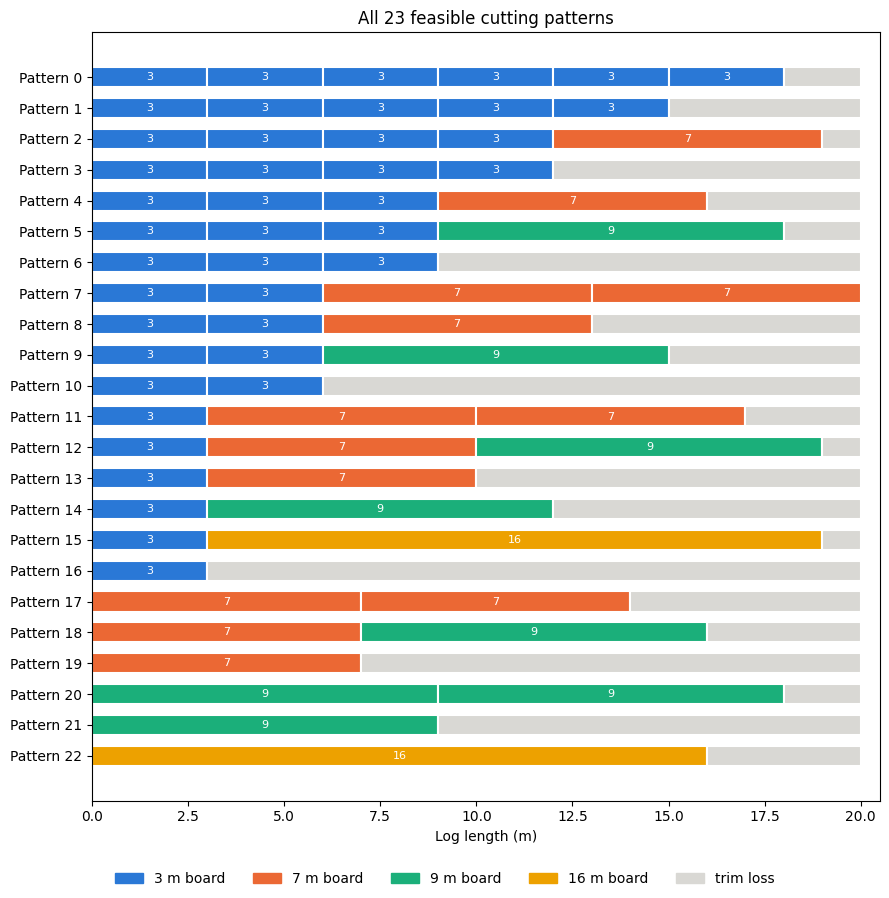

In [4]:
def plot_patterns(ax, patterns, types, length, counts=None, row_labels=None):
    """Draw each pattern as a horizontal log: colored segments are boards, gray is trim loss; counts labels the logs used"""
    for row, plan in enumerate(patterns):
        pos = 0
        for i, (a, l) in enumerate(zip(plan, types)):
            for _ in range(a):
                ax.barh(row, l, left=pos, color=COLORS[i], edgecolor='white', linewidth=1.5, height=0.65)
                ax.text(pos + l / 2, row, f'{l}', ha='center', va='center', fontsize=8, color='white')
                pos += l
        if pos < length:
            ax.barh(row, length - pos, left=pos, color=WASTE_COLOR, edgecolor='white', linewidth=1.5, height=0.65)
        if counts is not None:
            ax.text(length + 0.4, row, f'x {counts[row]} logs', va='center', fontsize=10)
    ax.set_yticks(range(len(patterns)))
    ax.set_yticklabels(row_labels or [f'Pattern {k}' for k in range(len(patterns))])
    ax.invert_yaxis()
    ax.set_xlim(0, length + (5 if counts is not None else 0.5))
    ax.set_xlabel('Log length (m)')


def pattern_legend(fig, types, ncol=None):
    """Add a legend at the bottom of the figure"""
    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[i]) for i in range(len(types))]
    handles.append(plt.Rectangle((0, 0), 1, 1, color=WASTE_COLOR))
    labels = [f'{l} m board' for l in types] + ['trim loss']
    fig.legend(handles, labels, loc='lower center', ncol=ncol or len(labels), frameon=False)


fig, ax = plt.subplots(figsize=(9, 9))
plot_patterns(ax, plans, types, length)
ax.set_title(f'All {num_plans} feasible cutting patterns')
pattern_legend(fig, types)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

The chart shows that only pattern 7 (3 m×2 + 7 m×2) uses the 20-m log completely, and four more patterns leave just 1 m of trim. Many patterns waste a lot: pattern 16, for instance, cuts a single 3-m board and leaves 17 m. The solver's job is to pick the right combination of these 23 patterns and decide how many logs to cut with each.

## Create the COPT Environment and COPT Model
Modeling with COPT starts by creating an environment `Envr` and then a model object `Model` inside it. All variables and constraints are added to this model object.

In [5]:
env = cp.Envr()
model = env.createModel("cutting_stock")

Cardinal Optimizer v8.0.6. Build date Aug  7 2026
Copyright Cardinal Operations 2026. All Rights Reserved


## Add three core components of COPT Model

### Add Decision Variables
Each cutting pattern gets one decision variable $x_j$, the number of logs cut with that pattern. Logs are used whole, so $x_j$ is a non-negative integer. With 23 patterns, `addVars()` creates all 23 variables in one call.

In [6]:
x = model.addVars(num_plans, lb=0, vtype=COPT.INTEGER, nameprefix='x')

<font color=#0000FF>
<b>Tip: Adding variables in batch with Model.addVars()</b>
</font>

The first argument of `Model.addVars()` can be an integer (creating variables indexed 0 to n-1) or any iterable such as a list or tuple. It returns a `tupledict` keyed by the indices, so individual variables are accessed as `x[j]`.

- `vtype=COPT.INTEGER` makes the variables integer; the other common types are `COPT.CONTINUOUS` (the default) and `COPT.BINARY` (0-1 variables).
- `nameprefix='x'` generates names of the form `x(0)`, `x(1)`, …, which makes debugging and exported model files easier to read.
- The lower bound `lb` defaults to 0; it is written explicitly here to mirror the non-negativity requirement of the mathematical model.

### Set Objective Function
The objective is to use as few logs as possible. Pattern $j$ uses $x_j$ logs, so the total is the sum over all patterns: `quicksum(x)` adds up all variables and `COPT.MINIMIZE` asks for the minimum.
$$
\min \, \sum_{j \in J} x_j
$$

In [7]:
model.setObjective(cp.quicksum(x), sense=COPT.MINIMIZE)

### Add Constraints
One constraint per board type $i$: the total number of type-$i$ boards produced by all patterns must be at least the demand $d_i$. One log of pattern $j$ yields `plans[j][i]` boards of type $i$, so $x_j$ logs yield `plans[j][i] * x[j]`, and the sum over all patterns is the total output.
$$
\sum_{j \in J} a_{ji} \cdot x_j \geq d_i, \quad \forall \, i \in I
$$

In [8]:
demand_cons = model.addConstrs(
    (cp.quicksum(plans[j][i] * x[j] for j in range(num_plans)) >= demand[i] for i in range(num_types)),
    nameprefix='demand')

print(f'Model size: {model.getAttr("Rows")} rows (constraints), {model.getAttr("Cols")} columns (variables)')

Model size: 4 rows (constraints), 23 columns (variables)


<font color=#0000FF>
<b>Tip: Adding constraints in batch with Model.addConstrs() and quicksum()</b>
</font>

- `Model.addConstrs(generator, nameprefix=...)` takes a generator expression and adds one constraint per item it yields. The return value is again a `tupledict`, so a single constraint is available as `demand_cons[i]`; this is used later when reading dual values.
- Linear expressions should be built with `cp.quicksum()` rather than Python's built-in `sum()`. The former is optimized for the solver's expression objects, and the difference in speed becomes noticeable as the number of terms grows.
- `Model.getAttr()` reads model-level attributes such as `"Rows"` (number of constraints) and `"Cols"` (number of variables); attribute names are case-insensitive.

## Solve
Calling `solve()` starts the optimization. COPT reports the model size, the presolve statistics and the progress of the branch-and-bound search in its log.

In [9]:
model.solve()

Model fingerprint: 2430e039

Using Cardinal Optimizer v8.0.6 on Linux (Ubuntu 24.04.4 LTS - x86_64)
The CPU model is Intel(R) Xeon(R) Processor @ 2.80GHz
Hardware has 2 physical cores and 2 logical cores. Using instruction set X86_AVX512_E1 (14)
Minimizing a MIP problem

The original problem has:
    4 rows, 23 columns and 36 non-zero elements
    23 integers

Starting the MIP solver with 2 threads and 4 tasks

Presolving the problem

The presolved problem has:
    4 rows, 23 columns and 36 non-zero elements
    23 integers

Problem info:
    Range of matrix coefficients:    [1e+00,6e+00]
    Range of rhs coefficients:       [8e+00,3e+01]
    Range of bound coefficients:     [5e+00,3e+01]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --     Inf  0.01s
H        0         1      --       0  0.00

<font color=#0000FF>
<b>Tip: How to read the COPT solver log</b>
</font>

The log begins with the model size (`4 rows, 23 columns`) and the size after presolving. The table in the middle traces the branch-and-bound search; the two most useful columns are `BestBound` (the lower bound proven so far, i.e. "the number of logs cannot be below this value") and `BestSolution` (the best integer solution found so far), and `Gap` is their relative difference. When the gap reaches 0, the solution found has been proven optimal.

At the end of the log, `Best solution` and `Best bound` give the final objective value and bound, `Solve time` is the elapsed time, and `Solution status : integer optimal` means an optimal integer solution has been found. The status is also available in code through `model.status`, which equals `COPT.OPTIMAL` when the solution is optimal.

## Retrieve Results
After a successful solve, the value of each variable is read with `x[j].x`; patterns whose value is positive are the ones actually used. Below, the plan is first printed as text (patterns, number of logs, output per board type and material utilization) and then plotted. Both routines are reused in the case expansion, so they are written as functions.

Minimum number of logs: 30

Cutting patterns used:
   x2 + 7m x2]  8 logs, trim loss 0 m per log
   x1 + 7m x1 + 9m x1]  14 logs, trim loss 1 m per log
   x1 + 16m x1]  8 logs, trim loss 1 m per log

Output by board type:
   3 m: demand  25, produced  38, surplus 13
   7 m: demand  30, produced  30, surplus  0
   9 m: demand  14, produced  14, surplus  0
  16 m: demand   8, produced   8, surplus  0

Total log length 600 m, total trim loss 22 m, material utilization 96.3%


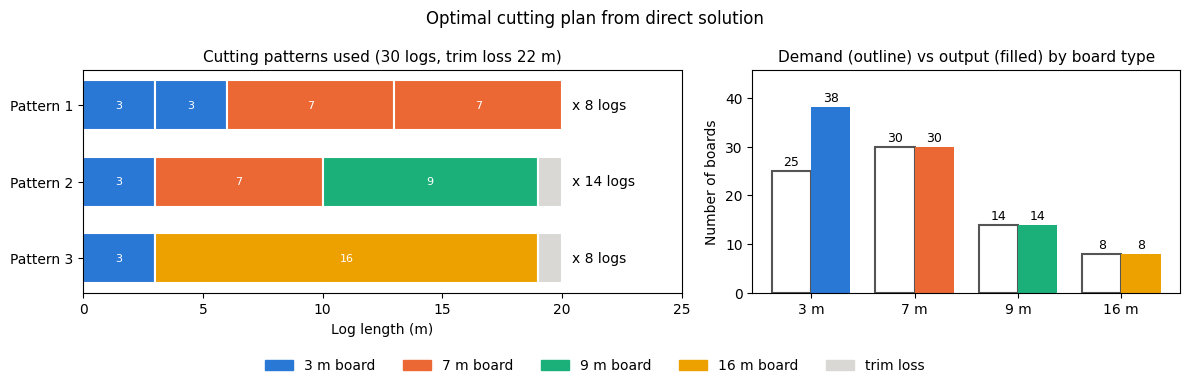

In [10]:
def print_solution(objval, used_plans, types, demand, length):
    """Print the solution; used_plans is [(pattern, number of logs), ...]"""
    total_logs = int(round(objval))
    print(f'Minimum number of logs: {total_logs}\n')
    print('Cutting patterns used:')
    total_waste = 0
    produced = [0] * len(types)
    for plan, cnt in used_plans:
        cnt = int(round(cnt))
        desc = ' + '.join(f'{l}m x{a}' for a, l in zip(plan, types) if a > 0)
        waste = length - sum(a * l for a, l in zip(plan, types))
        total_waste += waste * cnt
        for i, a in enumerate(plan):
            produced[i] += a * cnt
        print(f'  [{desc}]  {cnt} logs, trim loss {waste} m per log')
    print('\nOutput by board type:')
    for i, l in enumerate(types):
        print(f'  {l:>2} m: demand {demand[i]:>3}, produced {produced[i]:>3}, surplus {produced[i] - demand[i]:>2}')
    print(f'\nTotal log length {total_logs * length} m, total trim loss {total_waste} m, '
          f'material utilization {1 - total_waste / (total_logs * length):.1%}')


def plot_solution(used_plans, types, demand, length, title=''):
    """Left: patterns used and log counts; right: demand vs output per board type"""
    patterns = [p for p, _ in used_plans]
    counts = [int(round(c)) for _, c in used_plans]
    produced = [sum(p[i] * c for p, c in zip(patterns, counts)) for i in range(len(types))]
    total_logs = sum(counts)
    total_waste = sum((length - sum(a * l for a, l in zip(p, types))) * c for p, c in zip(patterns, counts))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={'width_ratios': [1.4, 1]})

    plot_patterns(ax1, patterns, types, length, counts=counts,
                  row_labels=[f'Pattern {k + 1}' for k in range(len(patterns))])
    ax1.set_title(f'Cutting patterns used ({total_logs} logs, trim loss {total_waste} m)', fontsize=11)

    xs = range(len(types))
    w = 0.38
    ax2.bar([k - w / 2 for k in xs], demand, w, facecolor='none', edgecolor='#555555', linewidth=1.5)
    ax2.bar([k + w / 2 for k in xs], produced, w, color=[COLORS[i] for i in xs])
    for k in xs:
        ax2.text(k - w / 2, demand[k] + 0.5, str(demand[k]), ha='center', va='bottom', fontsize=9)
        ax2.text(k + w / 2, produced[k] + 0.5, str(produced[k]), ha='center', va='bottom', fontsize=9)
    ax2.set_xticks(list(xs))
    ax2.set_xticklabels([f'{l} m' for l in types])
    ax2.set_ylabel('Number of boards')
    ax2.set_ylim(0, max(max(demand), max(produced)) * 1.2)
    ax2.set_title('Demand (outline) vs output (filled) by board type', fontsize=11)

    fig.suptitle(title, fontsize=12)
    pattern_legend(fig, types)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


if model.status == COPT.OPTIMAL:
    used = [(plans[j], x[j].x) for j in range(num_plans) if x[j].x > 0.5]
    print_solution(model.objval, used, types, demand, length)
    plot_solution(used, types, demand, length, title='Optimal cutting plan from direct solution')
else:
    print('No optimal solution found, status:', model.status)

The optimal plan uses 30 logs, 5 fewer than the simple approach of cutting one board length per log (35 logs), a 14% reduction. Only 3 of the 23 patterns are used: pattern 1 (3 m×2 + 7 m×2) uses the log completely, while pattern 2 (3 m×1 + 7 m×1 + 9 m×1) and pattern 3 (3 m×1 + 16 m×1) each leave 1 m of trim. Out of 600 m of logs only 22 m are wasted, a material utilization of 96.3%.

The left chart reveals the common rule behind the optimal patterns: every log is built around one long board, and 3-m boards fill up the remaining length. The right chart shows that the output of 7 m, 9 m and 16 m boards exactly equals the demand, while 13 extra 3-m boards are produced. The surplus is a by-product of the solver "filling leftovers with short pieces"; the extra short boards go into stock, which is more economical than leaving whole sections as waste. If overproduction is undesirable in practice, the demand constraints can be turned into equalities or a penalty on surplus boards can be added to the objective, without changing the structure of the model.

Note also the shape of the model: 4 rows, 23 columns, and only 3 columns positive in the optimal solution. The more board types there are, the more pronounced this "many columns, few rows, very few useful columns" pattern becomes, and it is exactly what the column generation algorithm in the case expansion exploits.

## Case Expansion: Speeding Up the Solution with Column Generation

As the number of board types grows, the number of feasible patterns increases rapidly and enumerating them before building the model stops being practical. Column generation starts from a few patterns and adds valuable ones based on the solution obtained so far. In code, this means repeating the following three steps:

1. Solve the **restricted master problem** (RMP: only the patterns currently available, with the integer variables relaxed to continuous ones) and obtain the **shadow price** $\pi_i$ of each demand constraint, i.e. the minimum number of additional logs needed if the demand for board type $i$ increased by one piece.
2. Solve the **pricing subproblem**: find the way of cutting one log that maximizes the total value $\sum_i \pi_i a_i$, where the "value" of each board is its shadow price. If the maximum exceeds 1 (the cost of one log), the pattern is worth more than it costs, its **reduced cost** $1 - \sum_i \pi_i a_i$ is negative, and adding it to the RMP reduces the number of logs.
3. **Add the new pattern to the RMP** as a new variable (column) and return to step 1. When the maximum value from the subproblem no longer exceeds 1, no pattern worth adding remains and the iteration stops.

Finally, the RMP variables are switched back to integer type and the model is solved once more to obtain the final cutting plan. The concepts are explained in detail in the case description; the focus here is on the COPT implementation.

### Build the Restricted Master Problem
The RMP is a reduced version of the original model: it keeps only a subset of the patterns and relaxes the integer variables to continuous ones.
$$
\begin{aligned}
    \min \quad & \sum_{j \in J_1} x_j \\
    \text{s.t.} \quad & \sum_{j \in J_1} a_{ji} \cdot x_j \geq d_i, \quad \forall \, i \in I \\
    & x_j \geq 0, \quad \forall \, j \in J_1
\end{aligned}
$$
The initial patterns are the four simplest ones: each log is cut into boards of a single type, as many as fit, i.e. `[6,0,0,0]`, `[0,2,0,0]`, `[0,0,2,0]` and `[0,0,0,1]`. These four patterns can cover every demand, so the RMP is feasible.

In [11]:
# Initial patterns: one board type per log
init_patterns = [[length // types[i] if k == i else 0 for k in range(num_types)] for i in range(num_types)]
print('Initial cutting patterns:', init_patterns)

model_rmp = env.createModel("restricted_master")
model_rmp.setParam("Logging", 0)

# Relaxed continuous variables; obj=1 means each pattern costs one log
y = model_rmp.addVars(num_types, lb=0, obj=1.0, vtype=COPT.CONTINUOUS, nameprefix='pattern')

rmp_cons = model_rmp.addConstrs(
    (cp.quicksum(init_patterns[j][i] * y[j] for j in range(num_types)) >= demand[i] for i in range(num_types)),
    nameprefix='demand')

Initial cutting patterns: [[6, 0, 0, 0], [0, 2, 0, 0], [0, 0, 2, 0], [0, 0, 0, 1]]


<font color=#0000FF>
<b>Tip: Setting objective coefficients through the obj argument</b>
</font>

Both `Model.addVar()` and `Model.addVars()` accept an `obj` argument that sets the variable's objective coefficient at creation time, so a separate call to `setObjective()` is not needed. Column generation keeps adding new variables to the model, and giving each one its cost directly in `addVar()` fits the flow of the algorithm.

`obj` only sets coefficients; the optimization direction is controlled by `Model.setObjSense()`, which defaults to minimization, so the RMP needs no explicit setting. Since the RMP and the subproblem are solved many times during the iteration, the solver log is switched off with `setParam("Logging", 0)` to keep the output readable.

### Build the Pricing Subproblem
The pricing subproblem is an integer knapsack problem: the log is 20 m long, a board of type $i$ is worth its shadow price $\pi_i$, and we look for the most valuable way of cutting the log. The decision variable $a_i$ is the number of type-$i$ boards in the new pattern.
$$
\begin{aligned}
    \max \quad & \sum_{i \in I} \pi_i \cdot a_i \\
    \text{s.t.} \quad & \sum_{i \in I} l_i \cdot a_i \leq L \\
    & a_i \in \mathbb{N}, \quad \forall \, i \in I
\end{aligned}
$$
The constraint of the subproblem (total length at most 20 m) never changes during the iteration; only the objective coefficients $\pi_i$ do. The subproblem is therefore built once, and only its objective coefficients are updated in each iteration.

In [12]:
model_pricing = env.createModel("pricing")
model_pricing.setParam("Logging", 0)

# a_i: number of type-i boards in the new pattern; the objective coefficients are set to the shadow prices in each iteration
a = model_pricing.addVars(num_types, lb=0, vtype=COPT.INTEGER, nameprefix='a')

model_pricing.addConstr(cp.quicksum(types[i] * a[i] for i in range(num_types)) <= length, name='length')

model_pricing.setObjSense(COPT.MAXIMIZE)

### Column Generation Iterations
The three steps are written as a loop: solve the RMP, read the shadow prices, update and solve the subproblem, decide whether to add a column. Each iteration prints the key figures and records the RMP objective and shadow prices in `history` for plotting. A tolerance of $10^{-6}$ is used in the termination test to avoid extra iterations caused by rounding.

In [13]:
generated_patterns = list(init_patterns)
history = []      # RMP objective and shadow prices per iteration, for plotting
iteration = 0

while True:
    # Solve the RMP and read the dual values (shadow prices) of the demand constraints
    model_rmp.solve()
    duals = model_rmp.getInfo("Dual", rmp_cons)
    pi = [duals[i] if abs(duals[i]) > 1e-9 else 0.0 for i in range(num_types)]
    history.append({'obj': model_rmp.objval, 'pi': pi})

    # Solve the pricing subproblem with the shadow prices as objective coefficients
    for i in range(num_types):
        a[i].setInfo("Obj", pi[i])
    model_pricing.solve()

    new_pattern = [int(round(a[i].x)) for i in range(num_types)]
    reduced_cost = 1 - model_pricing.objval
    print(f'Iteration {iteration}: RMP objective = {model_rmp.objval:.4f}, shadow prices = {[round(v, 3) for v in pi]}, '
          f'subproblem value = {model_pricing.objval:.4f}, reduced cost = {reduced_cost:.4f}')

    # Stop if the reduced cost is non-negative; otherwise add the new pattern to the RMP as a column
    if reduced_cost > -1e-6:
        print('        Reduced cost is non-negative: no improving pattern, stop')
        break
    print(f'        Add new pattern {new_pattern}')
    column = cp.Column([rmp_cons[i] for i in range(num_types)], new_pattern)
    model_rmp.addVar(lb=0, obj=1.0, vtype=COPT.CONTINUOUS,
                     name=f'pattern({len(generated_patterns)})', column=column)
    generated_patterns.append(new_pattern)
    iteration += 1

lp_bound = model_rmp.objval
print(f'\nColumn generation converged: {len(generated_patterns) - num_types} new pattern(s) generated, '
      f'{len(generated_patterns)} patterns in the RMP')
print(f'LP relaxation optimum z_LP = {lp_bound:.4f}, lower bound ceil(z_LP) = {math.ceil(lp_bound - 1e-6)}')

Iteration 0: RMP objective = 34.1667, shadow prices = [0.167, 0.5, 0.5, 1.0], subproblem value = 1.3333, reduced cost = -0.3333
        Add new pattern [2, 2, 0, 0]
Iteration 1: RMP objective = 30.0000, shadow prices = [0.0, 0.5, 0.5, 1.0], subproblem value = 1.0000, reduced cost = 0.0000
        Reduced cost is non-negative: no improving pattern, stop

Column generation converged: 1 new pattern(s) generated, 5 patterns in the RMP
LP relaxation optimum z_LP = 30.0000, lower bound ceil(z_LP) = 30


<font color=#0000FF>
<b>Tip: Reading dual values, modifying objective coefficients and adding columns</b>
</font>

The loop relies on three COPT features that column generation cannot do without:

- **Reading dual values**: `Model.getInfo("Dual", constrs)` returns the dual values of a group of constraints in one call; when a `tupledict` is passed in, a `tupledict` with the same indices is returned. For a single constraint, the attribute `constr.Pi` can be read directly. Dual values are available only after solving a linear program; they cannot be retrieved when the model contains integer variables.
- **Modifying objective coefficients**: `Var.setInfo("Obj", value)` overwrites the objective coefficient of one variable without calling `setObjective()` again. After the change, `solve()` warm-starts from the previous solution, which is very efficient for iterative algorithms that change only a few coefficients per round.
- **Adding columns**: `cp.Column(constrs, coeffs)` describes the coefficients of a new variable in each constraint, and `Model.addVar(..., column=column)` adds it to the model. Dual values, the new column and the `obj` argument together close the loop "obtain duals → price → add column".

The data recorded in `history` are plotted below: the RMP objective over the iterations on the left, and the shadow prices of the board types in each iteration on the right.

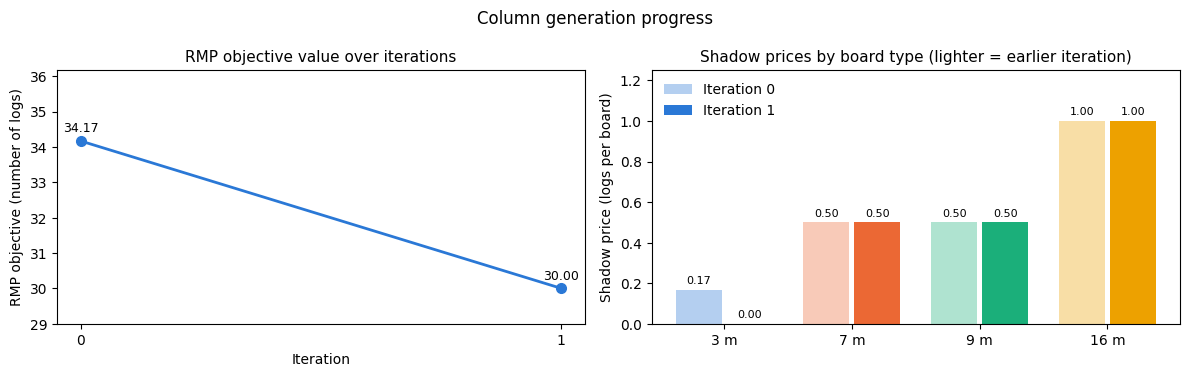

In [14]:
def plot_cg_progress(history, types, title=''):
    """Left: RMP objective over iterations; right: shadow prices per iteration"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
    its = list(range(len(history)))
    objs = [h['obj'] for h in history]

    ax1.plot(its, objs, marker='o', color=COLORS[0], linewidth=2, markersize=7)
    for k, v in zip(its, objs):
        ax1.text(k, v + (max(objs) - min(objs) + 1) * 0.05, f'{v:.2f}', ha='center', fontsize=9)
    ax1.set_xticks(its)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('RMP objective (number of logs)')
    ax1.set_ylim(min(objs) - 1, max(objs) + 2)
    ax1.set_title('RMP objective value over iterations', fontsize=11)

    n, m = len(types), len(history)
    w = 0.8 / m
    for k, h in enumerate(history):
        xs = [i + (k - (m - 1) / 2) * w for i in range(n)]
        ax2.bar(xs, h['pi'], w * 0.9, color=[COLORS[i] for i in range(n)],
                alpha=0.35 + 0.65 * k / max(1, m - 1), label=f'Iteration {k}')
        for xx, v in zip(xs, h['pi']):
            ax2.text(xx, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax2.set_xticks(range(n))
    ax2.set_xticklabels([f'{l} m' for l in types])
    ax2.set_ylabel('Shadow price (logs per board)')
    ax2.set_ylim(0, max(max(h['pi']) for h in history) * 1.25)
    ax2.set_title('Shadow prices by board type (lighter = earlier iteration)', fontsize=11)
    ax2.legend(frameon=False)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_cg_progress(history, types, title='Column generation progress')

In iteration 0 the RMP contains only the four single-type patterns and its objective is 34.17 logs (fractional, because "half a log" is allowed in the relaxation). The shadow prices are intuitive: a 3-m board is worth 1/6 of a log (six per log), a 7-m or 9-m board is worth half a log (two per log), and a 16-m board is worth a whole log. Searching for the most valuable pattern under these prices gives 3 m×2 + 7 m×2 with a value of $2 \times 0.167 + 2 \times 0.5 = 1.33$, more than the cost of one log, so it is added to the RMP.

In iteration 1, with the new pattern available, the RMP objective drops to 30 and the shadow prices change: the price of a 3-m board falls to 0, because it can now be supplied "for free" from the leftover of the new pattern without consuming additional logs. Solving the subproblem again, the highest value is exactly 1, no pattern has a negative reduced cost, and the iteration stops. The value 30 is the LP relaxation optimum $z_{LP}$: however the cutting is arranged, fewer than 30 logs is impossible.

### Restore Integrality and Retrieve the Results
When column generation converges, the RMP solution is optimal for the LP relaxation and is generally fractional. Switching the RMP variables to integer type and solving once more yields an integer solution over the generated patterns. If its objective equals the lower bound $\lceil z_{LP} \rceil$, it is the optimal solution of the original problem.

Minimum number of logs: 30

Cutting patterns used:
   x2]  2 logs, trim loss 6 m per log
   x2]  7 logs, trim loss 2 m per log
   x1]  8 logs, trim loss 4 m per log
   x2 + 7m x2]  13 logs, trim loss 0 m per log

Output by board type:
   3 m: demand  25, produced  26, surplus  1
   7 m: demand  30, produced  30, surplus  0
   9 m: demand  14, produced  14, surplus  0
  16 m: demand   8, produced   8, surplus  0

Total log length 600 m, total trim loss 58 m, material utilization 90.3%

The integer objective equals the lower bound ceil(z_LP) = 30: the solution is optimal.


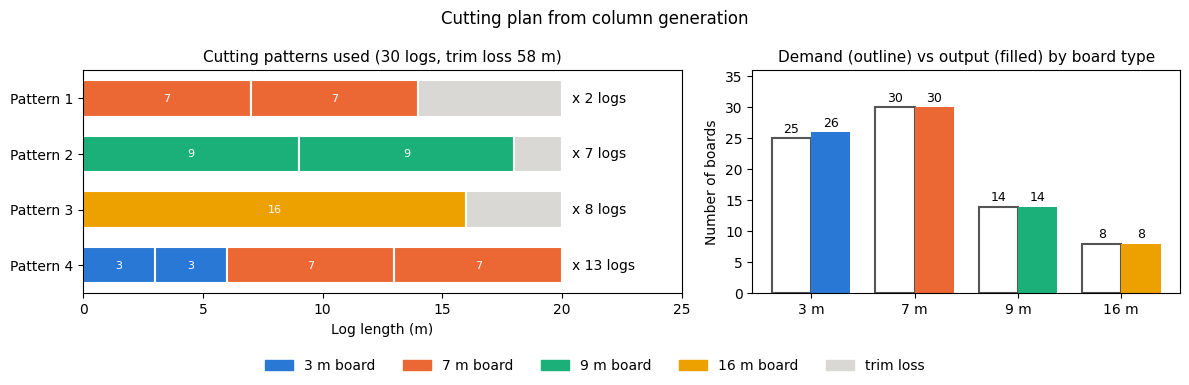

In [15]:
# Switch the variables to integer type on the same model
for var in model_rmp.getVars():
    var.setType(COPT.INTEGER)

model_rmp.solve()

if model_rmp.status == COPT.OPTIMAL:
    used_cg = []
    for var in model_rmp.getVars():
        if var.x > 0.5:
            # Recover the cutting pattern from the coefficients of the variable's column
            col = model_rmp.getCol(var)
            pattern = [0] * num_types
            for k in range(col.getSize()):
                pattern[col.getConstr(k).getIdx()] = int(round(col.getCoeff(k)))
            used_cg.append((pattern, var.x))
    print_solution(model_rmp.objval, used_cg, types, demand, length)

    lower_bound = math.ceil(lp_bound - 1e-6)
    if int(round(model_rmp.objval)) == lower_bound:
        print(f'\nThe integer objective equals the lower bound ceil(z_LP) = {lower_bound}: the solution is optimal.')
    else:
        print(f'\nInteger objective {int(round(model_rmp.objval))}, lower bound {lower_bound}: '
              f'the solution is at most {int(round(model_rmp.objval)) - lower_bound} log(s) from optimal.')
    plot_solution(used_cg, types, demand, length, title='Cutting plan from column generation')
else:
    print('No optimal solution found, status:', model_rmp.status)

<font color=#0000FF>
<b>Tip: Changing variable types with Var.setType() and reading columns with Model.getCol()</b>
</font>

- `Var.setType(COPT.INTEGER)` changes the type of a variable after the model has been built. Combined with `solve()`, it lets the same model object be solved first as an LP relaxation and then as an integer model, without rebuilding. Used the other way round, `setType(COPT.CONTINUOUS)` is a manual LP relaxation.
- `Model.getCol(var)` returns the column of a variable; `getSize()`, `getConstr(k)` and `getCoeff(k)` iterate over its non-zero coefficients. In column generation this is the direct way to look up which cutting pattern a variable stands for, without maintaining a separate mapping outside the model.

Column generation also arrives at a 30-log plan, equal to the lower bound $\lceil z_{LP} \rceil = 30$, so the plan is confirmed optimal. Only 5 patterns were involved (the 4 initial ones plus 1 generated), compared with the 23 enumerated by the direct approach.

Comparing the two result charts shows that the column generation plan differs from the direct one: both use 30 logs, but the trim loss is 58 m versus 22 m. The reason is that the objective counts logs only; neither trim loss nor surplus boards appear in it, so plans with the same number of logs are equally good as far as the model is concerned. In addition, column generation solves the integer model over just 5 patterns, which leaves fewer combinations to choose from. If trim loss matters in practice, a small penalty on it can be added to the objective so that, among plans with the same number of logs, the solver prefers the one with less waste.

### Comparison on a Larger Instance
The instance in this case is small, so the two approaches hardly differ. Below, both are wrapped in functions and compared on an instance with more board types.

Instance: log length 50 m, board lengths [4, 6, 7, 9, 11, 13], demands [80, 60, 90, 70, 50, 40]

Enumeration      : 1068 patterns, integer optimum 61, 0.108 s
Column generation: 12 patterns, LP optimum 60.200 (lower bound 61), integer objective 61, 0.020 s


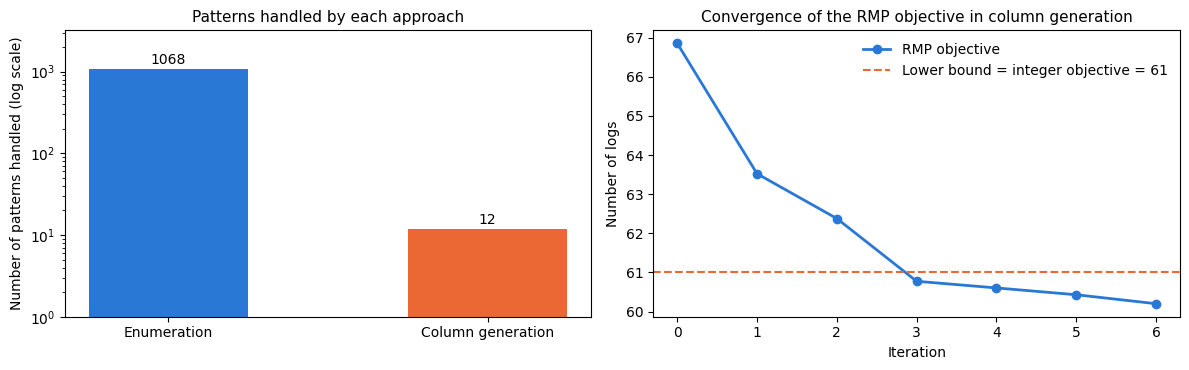

In [16]:
import time

def solve_by_enumeration(length, types, demand):
    """Enumerate all patterns and solve; returns (number of patterns, optimum, solve time)"""
    plans = enumerate_patterns(length, types)
    n, m = len(types), len(plans)
    model = env.createModel("enumeration")
    model.setParam("Logging", 0)
    x = model.addVars(m, vtype=COPT.INTEGER, nameprefix='x')
    model.setObjective(cp.quicksum(x), COPT.MINIMIZE)
    model.addConstrs((cp.quicksum(plans[j][i] * x[j] for j in range(m)) >= demand[i] for i in range(n)),
                     nameprefix='demand')
    t0 = time.time()
    model.solve()
    return m, model.objval, time.time() - t0


def solve_by_column_generation(length, types, demand):
    """Column generation; returns (number of patterns, LP optimum, integer objective, solve time, RMP objective per iteration)"""
    n = len(types)
    t0 = time.time()
    rmp = env.createModel("rmp")
    rmp.setParam("Logging", 0)
    init = [[length // types[i] if k == i else 0 for k in range(n)] for i in range(n)]
    y = rmp.addVars(n, obj=1.0, nameprefix='pattern')
    cons = rmp.addConstrs((cp.quicksum(init[j][i] * y[j] for j in range(n)) >= demand[i] for i in range(n)),
                          nameprefix='demand')

    pricing = env.createModel("pricing")
    pricing.setParam("Logging", 0)
    a = pricing.addVars(n, vtype=COPT.INTEGER, nameprefix='a')
    pricing.addConstr(cp.quicksum(types[i] * a[i] for i in range(n)) <= length, name='length')
    pricing.setObjSense(COPT.MAXIMIZE)

    num_patterns, rmp_objs = n, []
    while True:
        rmp.solve()
        rmp_objs.append(rmp.objval)
        pi = rmp.getInfo("Dual", cons)
        for i in range(n):
            a[i].setInfo("Obj", pi[i])
        pricing.solve()
        if 1 - pricing.objval > -1e-6:
            break
        column = cp.Column([cons[i] for i in range(n)], [a[i].x for i in range(n)])
        rmp.addVar(obj=1.0, name=f'pattern({num_patterns})', column=column)
        num_patterns += 1

    lp_obj = rmp.objval
    for var in rmp.getVars():
        var.setType(COPT.INTEGER)
    rmp.solve()
    return num_patterns, lp_obj, rmp.objval, time.time() - t0, rmp_objs


# Instance with 50-m logs and 6 board types
length2 = 50
types2  = [4, 6, 7, 9, 11, 13]
demand2 = [80, 60, 90, 70, 50, 40]

m_enum, obj_enum, t_enum = solve_by_enumeration(length2, types2, demand2)
m_cg, lp_cg, obj_cg, t_cg, rmp_objs = solve_by_column_generation(length2, types2, demand2)

print(f'Instance: log length {length2} m, board lengths {types2}, demands {demand2}\n')
print(f'Enumeration      : {m_enum} patterns, integer optimum {int(round(obj_enum))}, {t_enum:.3f} s')
print(f'Column generation: {m_cg} patterns, LP optimum {lp_cg:.3f} (lower bound {math.ceil(lp_cg - 1e-6)}), '
      f'integer objective {int(round(obj_cg))}, {t_cg:.3f} s')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
bars = ax1.bar(['Enumeration', 'Column generation'], [m_enum, m_cg], width=0.5, color=[COLORS[0], COLORS[1]])
for b, v in zip(bars, [m_enum, m_cg]):
    ax1.text(b.get_x() + b.get_width() / 2, v * 1.15, str(v), ha='center', fontsize=10)
ax1.set_yscale('log')
ax1.set_ylim(1, m_enum * 3)
ax1.set_ylabel('Number of patterns handled (log scale)')
ax1.set_title('Patterns handled by each approach', fontsize=11)

its = list(range(len(rmp_objs)))
ax2.plot(its, rmp_objs, marker='o', color=COLORS[0], linewidth=2, markersize=6, label='RMP objective')
lower_bound2 = math.ceil(lp_cg - 1e-6)
if int(round(obj_cg)) == lower_bound2:
    ax2.axhline(lower_bound2, color=COLORS[1], linestyle='--', linewidth=1.5,
                label=f'Lower bound = integer objective = {lower_bound2}')
else:
    ax2.axhline(lower_bound2, color=COLORS[1], linestyle='--', linewidth=1.5, label=f'Lower bound = {lower_bound2}')
    ax2.axhline(obj_cg, color=COLORS[2], linestyle=':', linewidth=1.5, label=f'Integer objective = {int(round(obj_cg))}')
ax2.set_xticks(its)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Number of logs')
ax2.set_title('Convergence of the RMP objective in column generation', fontsize=11)
ax2.legend(frameon=False)
plt.tight_layout()
plt.show()

On this instance, direct enumeration has to handle 1068 patterns, whereas column generation starts from 6 initial patterns and converges after adding only 6 columns, a difference of almost two orders of magnitude (the left chart uses a log scale). The right chart shows the RMP objective decreasing monotonically, quickly in the first few iterations and then more slowly, until it settles at the LP optimum of 60.2; the integer solution of 61 logs equals the lower bound $\lceil 60.2 \rceil = 61$ and is therefore optimal as well. With even more board types, the number of feasible patterns grows faster still and enumeration soon fails simply because the model becomes too large to build, while the number of columns column generation has to handle grows far more slowly.

It should be noted that solving the integer model only over the generated patterns is a heuristic: if the integer optimum needs a pattern that was never generated, this step misses it. In most practical problems the approach works well, and the lower bound $\lceil z_{LP} \rceil$ is always available to measure the quality of the solution. Guaranteeing integer optimality requires running column generation at every node of the branch-and-bound tree, the branch-and-price algorithm, which lies beyond the scope of this case.